## 1. Instalar Dependências 

In [6]:
!pip install -r requirements.txt

In [7]:
!playwright install chromium

## 2.  Importar Bibliotecas

In [ ]:
import pandas as pd
import json
from collections import Counter
import requests
import csv

## 3. Coletar Dados da API

**Código**: O código de assunto foi encontrado no site `https://www.cnj.jus.br/sgt/consulta_publica_assuntos.php`:
   1. Procure por "Medicamentos"
   2. Selecione a 4ª opção: `Fornecimento de medicamentos`
   3. Verifique o código que aparece, `12487 Fornecimento de medicamentos`

In [ ]:
url = "https://api-publica.datajud.cnj.jus.br/api_publica_tjce/_search"
api_key = "APIKey cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw=="

payload = json.dumps({
    "size": 10000,
    "query": {"match": {"assuntos.codigo": "12487"}}, # Código de assunto: `Fornecimento de medicamentos`
    "sort": [{"dataAjuizamento": {"order": "desc"}}]
})

headers = {
    'Authorization': api_key,
    'Content-Type': 'application/json'
}

response = requests.request("POST", url, headers=headers, data=payload)
dados_dict = response.json()
print(f"Total de processos encontrados na API: {dados_dict['hits']['total']['value']}")
print(f"Processos retornados nesta consulta: {len(dados_dict['hits']['hits'])}")

# Salvando em csv (números de processos para referência)
processos = dados_dict["hits"]["hits"]

numeros = []
for processo in processos:
    numero_processo = processo["_source"]["numeroProcesso"]
    numeros.append(numero_processo)

Total de processos encontrados na API: 6046
Processos retornados nesta consulta: 6046


## 4. Processamento dos Dados (Python Dataframe)

In [4]:
# Extrair dados dos processos
processos = []

for hit in dados_dict['hits']['hits']:
    processo = hit['_source']
    numero_processo = processo['numeroProcesso']
    grau = processo['grau']
    classe = processo['classe']['nome']
    assuntos = processo['assuntos']
    data_ajuizamento = processo['dataAjuizamento']
    ultima_atualizacao = processo['dataHoraUltimaAtualizacao']
    formato = processo['formato']['nome']
    codigo = processo['orgaoJulgador']['codigo']
    orgao_julgador = processo['orgaoJulgador']['nome']
    municipio = processo['orgaoJulgador']['codigoMunicipioIBGE']
    
    try:
        movimentos = processo['movimentos']
    except:
        movimentos = []
    
    processos.append([numero_processo, classe, data_ajuizamento, ultima_atualizacao, formato,
                     codigo, orgao_julgador, municipio, grau, assuntos, movimentos])

df = pd.DataFrame(processos, columns=['numero_processo', 'classe', 'data_ajuizamento', 'ultima_atualizacao',
                                      'formato', 'codigo', 'orgao_julgador', 'municipio', 'grau', 'assuntos', 'movimentos'])

print(f"Total de processos no DataFrame: {len(df)}")
df.sample(5)

Total de processos no DataFrame: 6046


,numero_processo,classe,data_ajuizamento,ultima_atualizacao,formato,codigo,orgao_julgador,municipio,grau,assuntos,movimentos
2551,30248407520238060001,Procedimento Comum Cível,20230710000000,2025-10-13T12:17:42.065Z,Eletrônico,17226,15ª VARA DA FAZENDA PUBLICA DA COMARCA DE FORT...,2304400,G1,"[{'codigo': 12487, 'nome': 'Fornecimento de me...","[{'complementosTabelados': [{'codigo': 2, 'val..."
1679,02104149120248060001,Procedimento Comum Cível,20240219000000,2024-08-31T06:08:50.194Z,Eletrônico,8701,3ª VARA DA INFANCIA E JUVENTUDE DA COMARCA DE ...,2304400,G1,"[{'codigo': 12487, 'nome': 'Fornecimento de me...","[{'complementosTabelados': [{'codigo': 4, 'val..."
629,02652094720248060001,Apelação / Remessa Necessária,20241105000000,2025-04-04T23:45:34.834Z,Eletrônico,50904,GADES - JOSE TARCILIO SOUZA DA SILVA,2304400,G2,"[{'codigo': 12487, 'nome': 'Fornecimento de me...","[{'codigo': 493, 'nome': 'Entrega em carga/vis..."
767,01588748720138060001,Apelação Cível,20240924000000,2025-07-11T14:03:16.846Z,Eletrônico,87013,GADES - FRANCISCO JAIME MEDEIROS NETO,2304400,G2,"[{'codigo': 12487, 'nome': 'Fornecimento de me...","[{'codigo': 493, 'nome': 'Entrega em carga/vis..."
5422,02335875220218060001,Procedimento Comum Cível,20210519000000,2025-06-10T20:27:07.928Z,Eletrônico,8505,23ª VARA CIVEL DA COMARCA DE FORTALEZA,2304400,G1,"[{'codigo': 12487, 'nome': 'Fornecimento de me...","[{'complementosTabelados': [{'codigo': 19, 'va..."


## 5. Análise de Decisões
Buscando pelos seguintes termos nos movimentos:
1. "Procedência"
2. "Improcedência"
3. "Improcedência do pedido e improcedência do pedido contraposto"
4. "Procedência do pedido e procedência do pedido contraposto"

In [5]:
# Extrair decisões dos movimentos
decisoes_por_processo = []
tipos_decisao_contagem = []

for idx, row in df.iterrows():
    numero = row['numero_processo']
    movimentos = row['movimentos']
    grau = row['grau']
    
    decisoes_encontradas = []

    if movimentos:
        for mov in movimentos:
            nome_mov = mov.get('nome', '')
            
            termos_decisao = [
                "Procedência",
                "Improcedência",
                "Improcedência do pedido e improcedência do pedido contraposto",
                "Procedência do pedido e procedência do pedido contraposto"
            ]
            
            # Identificar decisões
            if (any(palavra in nome_mov for palavra in termos_decisao) and grau == 'G1') :
                decisoes_encontradas.append(nome_mov)
                tipos_decisao_contagem.append(nome_mov)

    if decisoes_encontradas:
        decisoes_por_processo.append({
            'numero_processo': numero,
            'decisoes': decisoes_encontradas
        })

print(f"Processos com decisões: {len(decisoes_por_processo)} de {len(df)}")
print(f"\nTipos de decisões encontradas:")
for tipo, count in Counter(tipos_decisao_contagem).most_common(10):
    print(f"  {tipo}: {count}")

Processos com decisões: 1799 de 6046

Tipos de decisões encontradas:
  Procedência: 1284
  Procedência em Parte: 259
  Improcedência: 222
  Procedência em parte do pedido e improcedência do pedido contraposto: 30
  Improcedência do pedido e improcedência do pedido contraposto: 14
  Procedência do pedido e improcedência do pedido contraposto: 5
  Procedência do Pedido - Reconhecimento pelo réu: 3
  Procedência em parte do pedido e procedência do pedido contraposto: 1
  Procedência do pedido e procedência do pedido contraposto: 1


## 6. Separando um DataFrame somente com números e decisões

In [6]:
# Criar DataFrame de decisões
decisoes_lista = []

for item in decisoes_por_processo:
    for decisao in item['decisoes']:
        decisoes_lista.append({
            'numero_processo': item['numero_processo'],
            'tipo_decisao': decisao,
        })

df_decisoes = pd.DataFrame(decisoes_lista)
df_decisoes = df_decisoes.drop_duplicates(subset='numero_processo', keep='first')
df_decisoes.head(10)

,numero_processo,tipo_decisao
0,30039390220258060071,Improcedência
1,02187331420258060001,Procedência
2,30465508320258060001,Procedência em Parte
3,30415587920258060001,Procedência em Parte
4,30048329320258060167,Procedência
5,02162085920258060001,Procedência
6,30355412720258060001,Procedência
7,30022788520258060071,Procedência
8,30303751420258060001,Procedência em Parte
9,30292622520258060001,Procedência


## 7. Selecionando todos os registros

**Incluindo todos os tipos de decisão:**
  - Procedência
  - Improcedência
  - Improcedência do pedido e improcedência do pedido contraposto
  - Procedência do pedido e procedência do pedido contraposto

In [8]:
# Separar decisões por tipo
df_procedencia = df_decisoes[df_decisoes['tipo_decisao'] == 'Procedência'].copy()
df_improcedencia = df_decisoes[df_decisoes['tipo_decisao'] == 'Improcedência'].copy()
df_improcedencia_contraposto = df_decisoes[df_decisoes['tipo_decisao'] == 'Improcedência do pedido e improcedência do pedido contraposto'].copy()
df_procedencia_contraposto = df_decisoes[df_decisoes['tipo_decisao'] == 'Procedência do pedido e procedência do pedido contraposto'].copy()

# NOVA ESTRATÉGIA: Pegar TODOS os registros (sem seleção estratificada)
df_decisoes_completo = pd.concat([
    df_procedencia,
    df_improcedencia,
    df_improcedencia_contraposto,
    df_procedencia_contraposto
])

print(f"\n=== TODOS OS REGISTROS COM DECISÃO ===")
print(f"Total de registros: {len(df_decisoes_completo)}")
print(f"\nDistribuição por tipo:")
print(f"  - Procedência: {len(df_procedencia)}")
print(f"  - Improcedência: {len(df_improcedencia)}")
print(f"  - Improcedência (contraposto): {len(df_improcedencia_contraposto)}")
print(f"  - Procedência (contraposto): {len(df_procedencia_contraposto)}")

# Mostrar distribuição
df_decisoes_completo.head(10)


=== TODOS OS REGISTROS COM DECISÃO ===
Total de registros: 1497

Distribuição por tipo:
  - Procedência: 1264
  - Improcedência: 219
  - Improcedência (contraposto): 13
  - Procedência (contraposto): 1


,numero_processo,tipo_decisao
1,02187331420258060001,Procedência
4,30048329320258060167,Procedência
5,02162085920258060001,Procedência
6,30355412720258060001,Procedência
7,30022788520258060071,Procedência
9,30292622520258060001,Procedência
13,30012724320258060071,Procedência
14,30193154420258060001,Procedência
15,30186884020258060001,Procedência
16,30182752720258060001,Procedência


## 6. Exportar Resultados

In [7]:
df.to_csv('data/csv/processos_completo.csv', sep=',', header=True, index=False)
df_decisoes_completo.to_csv('data/csv/decisoes_resumo.csv', sep=',', header=True, index=False)

# Salvar números de processos completos em CSV
numeros_completos = df_decisoes_completo['numero_processo'].unique()
with open('data/csv/numeros_processos.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['numeroProcesso'])
    for num in numeros_completos:
        writer.writerow([num])

# Salvar dados completos em JSON (todos os processos com decisão)
processos_completos = [p for p in dados_dict['hits']['hits'] if p['_source']['numeroProcesso'] in numeros_completos]
dados_completos_todos = {
    'hits': {
        'hits': processos_completos,
        'total': {'value': len(processos_completos)}
    }
}

with open('data/json/dados_completos.json', 'w', encoding='utf-8') as f:
    json.dump(dados_completos_todos, f, indent=2, ensure_ascii=False)

# Salvar processos com decisões
with open('data/json/processos_com_decisoes.json', 'w', encoding='utf-8') as f:
    json.dump(decisoes_por_processo, f, indent=2, ensure_ascii=False)

print("\n=== ARQUIVOS EXPORTADOS ===")
print(f"  - data/csv/processos_completo.csv")
print(f"  - data/csv/decisoes_resumo.csv ({len(df_decisoes_completo)} registros)")
print(f"  - data/csv/numeros_processos.csv ({len(numeros_completos)} processos únicos)")
print(f"  - data/json/dados_completos.json ({len(processos_completos)} processos)")
print(f"  - data/json/processos_com_decisoes.json")

NameError: name 'df' is not defined

## 7. Coleta de Dados para o DataSet

Após gerar os arquivos básicos acima, crie a função `executar_script` para mostrar o andamento dos próximos processos no terminal do Jupyter:

In [8]:
import subprocess
import sys

def executar_script(script_name) -> bool:
    """
    Executa um script Python externo e exibe sua saída em tempo real no Jupyter
    
    Args:
        script_name (str): Nome do arquivo .py a ser executado
        
    Returns:
        bool: True se executou com sucesso, False se houve erro
    """

    processo = subprocess.Popen(
        # sys.executable = caminho do Python atual (mesmo do Jupyter)
        # '-u' = unbuffered mode (saída imediata, sem esperar buffer encher)
        [sys.executable, '-u', script_name],
        stdout=subprocess.PIPE,       # Captura prints dos scripts
        stderr=subprocess.STDOUT,     # Captura erros dos scripts
        text=True,                    # Retornar strings 
        encoding='utf-8',             # UTF-8 para caracteres especiais
        bufsize=0                     # Sem buffer, para mostrar linha a linha
    )
    
    while True:
        # Ler uma linha do output
        linha = processo.stdout.readline()
        
        # Verificar se acabou:
        # - linha vazia && processo terminou
        if not linha and processo.poll() is not None:
            break  
        
        if linha:
            print(linha)    
            sys.stdout.flush()         # Força exibir imediatamente (importante para Jupyter)

    processo.wait()
    
    if processo.returncode != 0:
        return False
    return True

FileNotFoundError: [WinError 2] O sistema não pode encontrar o arquivo especificado

## 8. Execução dos scripts Python

Em ordem de execução, os códigos realizam:

1. **Scraping** - Coleta nome do juiz(a), requerente e texto da decisão dos processos coletados via API do TJCE
2. **Inferência de Sexo** - Infere sexo dos nomes
3. **Geração de Features** - Gera dataset com 22 features

### Arquivos Gerados
- `data/csv/dados_processos_tjce.csv` - Dados do scraping
- `data/csv/dados_processos_com_sexo.csv` - Dados + sexo inferido
- `data/csv/dataset.csv` - Dataset final

In [ ]:
executar_script('scraper_tjce.py')
executar_script('inferir_sexo.py')
executar_script('gerar_features.py')


In [21]:
!pip install transformers torch imbalanced-learn tensorflow scikit-learn

In [ ]:
# -------------------------------------------
# REDE NEURAL + LEGAL-BERT + SMOTE
# Classificação: sentença procedente vs improcedente
# -------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import torch
from transformers import AutoTokenizer, AutoModel

from tensorflow.keras import models, layers, callbacks

# -----------------------------
# 1. Carregar dados
# -----------------------------
caminho_arquivo = "data/csv/dataset.csv"  # ajuste se necessário
df = pd.read_csv(caminho_arquivo)

# Conferir colunas principais (comentado, só para debug)
# print(df.columns)

# Alvo: 1 = procedente/favorável, 0 = improcedente
TARGET_COL = "sentenca_favoravel"
TEXT_COL   = "texto_decisao"

# Vamos guardar o sexo do juiz para análise de métricas por grupo depois
SEXO_JUIZ_COL = "sexo_juiz_bin"

# -----------------------------
# 2. Separar X (features) e y (alvo)
# -----------------------------
y = df[TARGET_COL].values  # 0/1

# Features numéricas: todas menos alvo e texto
cols_features_numericas = df.columns.difference([TARGET_COL, TEXT_COL])
X_num = df[cols_features_numericas].astype(float).copy()

# Também vamos salvar separado o sexo do juiz (antes do split)
sexo_juiz = df[SEXO_JUIZ_COL].values  # 1 = homem, 0 = mulher, -1 = desconhecido (p.ex.)

textos = df[TEXT_COL].astype(str).tolist()

print("Formato X_num:", X_num.shape)
print("Distribuição do alvo:", np.bincount(y))

# -----------------------------
# 3. Carregar Legal-BERT
# -----------------------------
# Modelo Legal-BERT em português (Hugging Face)
# Troque o nome se você usar outro modelo.
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()

# -----------------------------
# 4. Função para gerar embeddings Legal-BERT
# -----------------------------
def gerar_embeddings_legalbert(lista_textos, batch_size=16, max_length=512):
    """
    Recebe uma lista de strings e devolve um array (n_amostras, hidden_size)
    com o embedding do token [CLS] de cada texto.
    """
    embeddings = []

    for i in range(0, len(lista_textos), batch_size):
        batch_texts = lista_textos[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = bert_model(**encoded)
            # Usando o embedding do token [CLS]
            cls_embed = outputs.last_hidden_state[:, 0, :]  # (batch, hidden_size)
            embeddings.append(cls_embed.cpu().numpy())

    embeddings = np.vstack(embeddings)  # (n_amostras, hidden_size)
    return embeddings

print("Gerando embeddings Legal-BERT (pode demorar um pouco na primeira vez)...")
X_bert = gerar_embeddings_legalbert(textos, batch_size=16)
print("Formato X_bert:", X_bert.shape)

# -----------------------------
# 5. Padronizar features numéricas e concatenar com BERT
# -----------------------------
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num.values)

# Concatenar: [features numéricas escaladas | embeddings BERT]
X_total = np.hstack([X_num_scaled, X_bert]).astype("float32")
print("Formato X_total (numéricas + BERT):", X_total.shape)

# -----------------------------
# 6. Train-test split (estratificado)
# -----------------------------
X_train, X_test, y_train, y_test, sexo_juiz_train, sexo_juiz_test = train_test_split(
    X_total,
    y,
    sexo_juiz,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Distribuição y_train:", np.bincount(y_train))
print("Distribuição y_test :", np.bincount(y_test))

# -----------------------------
# 7. Balancear com SMOTE (apenas no treino)
# -----------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribuição após SMOTE (treino):", np.bincount(y_train_res))

# -----------------------------
# 8. Definir a rede neural (Keras)
# -----------------------------
input_dim = X_train_res.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")  # saída binária
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Early stopping para evitar overfitting
es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# 9. Treinar o modelo
# -----------------------------
history = model.fit(
    X_train_res,
    y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

# -----------------------------
# 10. Avaliar no conjunto de teste
# -----------------------------
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\n=== MATRIZ DE CONFUSÃO (GERAL) ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO (GERAL) ===")
print(classification_report(y_test, y_pred, digits=4))

# -----------------------------
# 11. Métricas por sexo do juiz
#     (0 = mulher, 1 = homem, -1 = desconhecido)
# -----------------------------
def relatorio_por_sexo(sexo_valor, descricao):
    mask = (sexo_juiz_test == sexo_valor)
    if mask.sum() == 0:
        print(f"\nNenhum caso encontrado para {descricao}.")
        return
    print(f"\n=== RELATÓRIO PARA {descricao} ===")
    print("Total de casos no teste:", mask.sum())
    print(confusion_matrix(y_test[mask], y_pred[mask]))
    print(classification_report(y_test[mask], y_pred[mask], digits=4))

relatorio_por_sexo(1, "JUÍZ HOMEM (sexo_juiz_bin = 1)")
relatorio_por_sexo(0, "JUÍZA MULHER (sexo_juiz_bin = 0)")
relatorio_por_sexo(-1, "SEXO DO JUIZ DESCONHECIDO (sexo_juiz_bin = -1)")

# Agora você tem:
# - Um modelo de rede neural com todas as features + Legal-BERT
# - Dados de treino balanceados com SMOTE
# - Avaliação geral e separada por sexo do juiz


Formato X_num: (769, 41)
Distribuição do alvo: [115 654]
Gerando embeddings Legal-BERT (pode demorar um pouco na primeira vez)...


In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [36]:
# -----------------------------
# GRÁFICO 1: Curva ROC (treino + teste)
# -----------------------------
from sklearn.metrics import roc_curve, auc

# Probabilidades de treino
y_pred_train_prob = model.predict([X_train_bert, X_train_meta])

# Curva ROC - treino
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

# Curva ROC - teste
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_prob)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6, 6))
plt.plot(fpr_train, tpr_train, label=f"Treino (AUC = {roc_auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Teste (AUC = {roc_auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
plt.xlabel("Falso Positivo (FPR)")
plt.ylabel("Verdadeiro Positivo (TPR)")
plt.title("Curva ROC - Sentença procedente vs improcedente")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'X_train_bert' is not defined

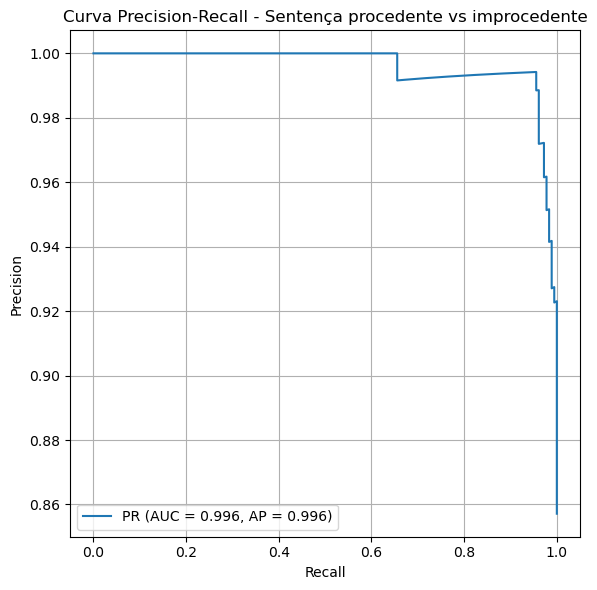

In [30]:
# -----------------------------
# GRÁFICO 2: Curva Precision-Recall
# -----------------------------
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
ap = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"PR (AUC = {pr_auc:.3f}, AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Sentença procedente vs improcedente")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
# -----------------------------
# GRÁFICO 3: Histórico de loss (treino x validação + teste)
# -----------------------------
loss_test, acc_test = model.evaluate([X_test_bert, X_test_meta], y_test, verbose=0)

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Loss treino")
plt.plot(history.history["val_loss"], label="Loss validação")

# marcador do teste
plt.scatter(len(history.history["loss"]) - 1, loss_test, marker="o", s=80,
            label=f"Loss teste = {loss_test:.4f}")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Histórico de Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'X_test_bert' is not defined